### ***AI  Based Crop Recommendation and Soil Condition Prediction***

##### ***Pre-Processing Data***

In [1]:
import numpy as np
import pandas as pd

###### *Reading Crops Data of State Jharkhand collected from various platforms*

In [2]:
crop_data = pd.read_csv("jharkhand_crop_dataset.csv")

In [3]:
crop_data.head(5)

,District,Humidity_%,Temperature_C,Rainfall_mm,N,P,K,pH,Crop_Name
0,LATEHAR,45.9,10.2,102,125.446667,122.486667,134.860000,6.47525,Wheat
1,GUMLA,43.7,14.0,218,110.806667,131.293333,132.940000,6.30250,Wheat
2,LATEHAR,44.8,25.9,238,125.446667,122.486667,134.860000,6.47525,Pulses
3,KHUNTI,58.8,32.4,545,125.346667,129.073333,131.340000,6.37360,Maize
4,WEST SINGHBHUM,80.1,35.9,1033,112.540000,146.546667,128.533333,6.49580,Paddy


In [4]:
crop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District       600 non-null    object 
 1   Humidity_%     600 non-null    float64
 2   Temperature_C  600 non-null    float64
 3   Rainfall_mm    600 non-null    int64  
 4   N              600 non-null    float64
 5   P              600 non-null    float64
 6   K              600 non-null    float64
 7   pH             600 non-null    float64
 8   Crop_Name      600 non-null    object 
dtypes: float64(6), int64(1), object(2)
memory usage: 42.3+ KB


###### *No need of cleaning already, data is cleaned*

In [5]:
crop_data.describe()

,Humidity_%,Temperature_C,Rainfall_mm,N,P,K,pH
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,55.293667,23.543500,458.390000,104.899167,143.163333,130.783056,6.428029
std,19.489725,7.272816,440.689676,14.810991,15.724708,9.780249,0.315686
min,24.200000,9.600000,10.000000,79.680000,116.120000,109.153333,5.889650
25%,38.800000,16.675000,108.000000,92.346667,131.953333,125.531667,6.267400
50%,52.500000,25.350000,279.000000,103.820000,142.250000,133.290000,6.395800
75%,66.050000,29.500000,702.000000,115.203333,147.893333,137.231667,6.632000
max,96.300000,36.800000,1615.000000,132.280000,183.586667,148.753333,6.983350


In [6]:
crop_data = crop_data.drop(columns=['District'])

In [7]:
crops_data_num = crop_data.select_dtypes(include=np.number)

<Axes: >

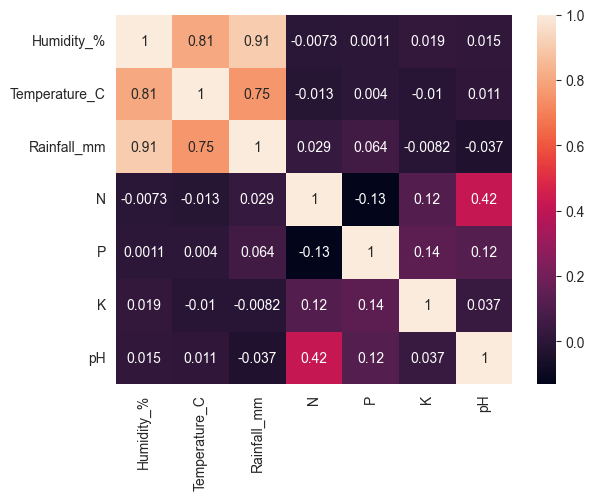

In [8]:
import seaborn as sns
sns.heatmap(crops_data_num.corr(), annot=True)

#### ***Supervised Learning***

##### *Creating Pipelines*

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import RocCurveDisplay,confusion_matrix

In [10]:
crop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Humidity_%     600 non-null    float64
 1   Temperature_C  600 non-null    float64
 2   Rainfall_mm    600 non-null    int64  
 3   N              600 non-null    float64
 4   P              600 non-null    float64
 5   K              600 non-null    float64
 6   pH             600 non-null    float64
 7   Crop_Name      600 non-null    object 
dtypes: float64(6), int64(1), object(1)
memory usage: 37.6+ KB


In [11]:
num = ['N', 'P', 'K', 'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm']

In [12]:
pipeline1 = Pipeline(
    steps = [
        ("Encoding",OneHotEncoder())
    ]
)

In [13]:
pipeline2 = Pipeline(
    steps = [
        ("Scaling",StandardScaler())
    ]
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",pipeline2,num)
    ]
)

In [15]:
X = crop_data.iloc[:,:-1]
Y = crop_data.iloc[:,-1:]


In [16]:
y = Y[['Crop_Name']].values
Y = y.ravel()

In [17]:
encoder = LabelEncoder()

##### *Data Splitting for Training model*

In [18]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.05,random_state=42)

In [19]:
Y_train.reshape(-1,1)

array([['Paddy'],
       ['Wheat'],
       ['Paddy'],
       ['Wheat'],
       ['Mustard'],
       ['Mustard'],
       ['Paddy'],
       ['Wheat'],
       ['Maize'],
       ['Maize'],
       ['Paddy'],
       ['Maize'],
       ['Pulses'],
       ['Pulses'],
       ['Paddy'],
       ['Paddy'],
       ['Mustard'],
       ['Pulses'],
       ['Pulses'],
       ['Pulses'],
       ['Pulses'],
       ['Wheat'],
       ['Wheat'],
       ['Paddy'],
       ['Pulses'],
       ['Pulses'],
       ['Maize'],
       ['Paddy'],
       ['Pulses'],
       ['Mustard'],
       ['Maize'],
       ['Pulses'],
       ['Mustard'],
       ['Paddy'],
       ['Pulses'],
       ['Maize'],
       ['Pulses'],
       ['Maize'],
       ['Paddy'],
       ['Mustard'],
       ['Wheat'],
       ['Mustard'],
       ['Wheat'],
       ['Mustard'],
       ['Paddy'],
       ['Mustard'],
       ['Wheat'],
       ['Wheat'],
       ['Pulses'],
       ['Wheat'],
       ['Mustard'],
       ['Paddy'],
       ['Paddy'],
       ['Must

In [20]:
Y_train = encoder.fit_transform(Y_train)
Y_test = encoder.transform(Y_test)

##### *Random Forest Classifier*

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
rf = RandomForestClassifier(n_estimators=100,n_jobs=-1,max_depth=20,random_state=42)

In [23]:
pipeline_rf = Pipeline(
    steps = [
        ("preprocess",preprocessor),
        ("random forest",rf)
    ]
)

In [24]:
pipeline_rf.fit(X_train,Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Scaling',
                                                                   StandardScaler())]),
                                                  ['N', 'P', 'K',
                                                   'Temperature_C',
                                                   'Humidity_%', 'pH',
                                                   'Rainfall_mm'])])),
                ('random forest',
                 RandomForestClassifier(max_depth=20, n_jobs=-1,
                                        random_state=42))])

In [25]:
pred_rf = pipeline_rf.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [27]:
pred_rf

array([3, 2, 4, 1, 2, 0, 1, 1, 3, 4, 0, 1, 2, 3, 4, 4, 0, 2, 4, 2, 3, 4,
       4, 2, 4, 3, 0, 4, 2, 0])

In [28]:
acc_rf = accuracy_score(Y_test,pred_rf) * 100
pre_rf = precision_score(Y_test,pred_rf,average='weighted', zero_division=0) * 100
recall_rf = recall_score(Y_test,pred_rf,average='weighted', zero_division=0) * 100
f1_rf = f1_score(Y_test,pred_rf,average='weighted', zero_division=0) * 100

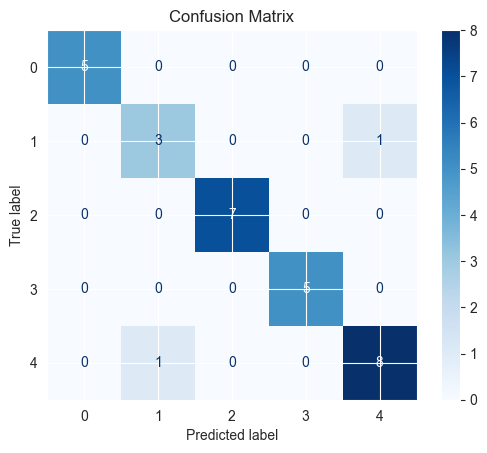

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(pipeline_rf, X_test, Y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [30]:
cm = confusion_matrix(Y_test, pred_rf)

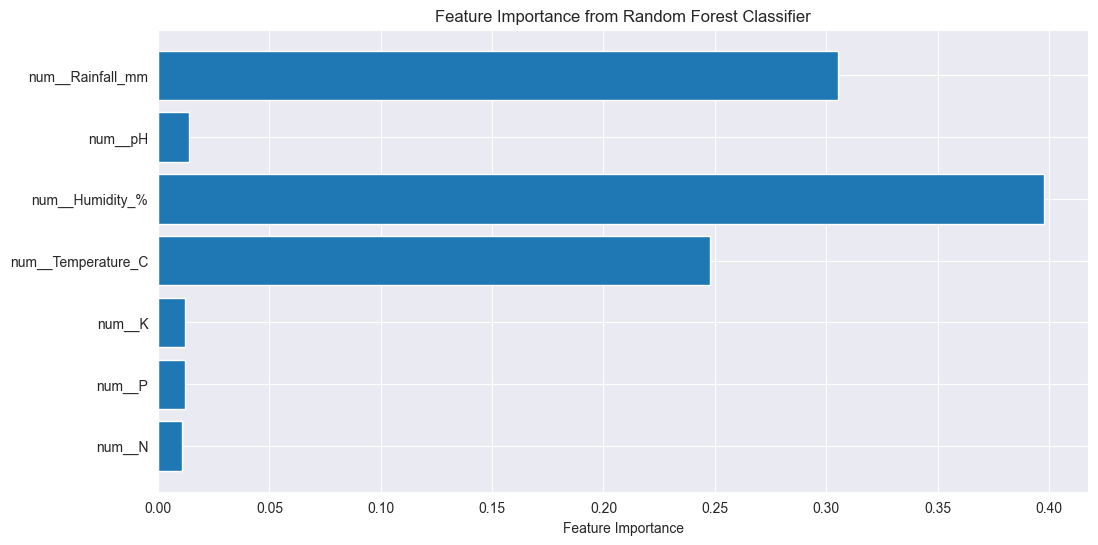

In [31]:
import matplotlib.pyplot as plt
rf_model = pipeline_rf.named_steps['random forest']
importances = rf_model.feature_importances_
feature_names = pipeline_rf.named_steps['preprocess'].get_feature_names_out()
plt.figure(figsize=(12, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance from Random Forest Classifier')
plt.show()  

##### *XG BOOST*

In [32]:
import xgboost as xg

In [33]:
xgb = xg.XGBClassifier(n_estimators=200,random_state=42,learning_rate = 0.5,max_depth = 10,objective="multi:softmax")

In [34]:
pipeline_xgb = Pipeline(
    steps = [
        ("preprocess",preprocessor),
        ("XG Boost",xgb)
    ]
)

In [35]:
pipeline_xgb.fit(X_train,Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Scaling',
                                                                   StandardScaler())]),
                                                  ['N', 'P', 'K',
                                                   'Temperature_C',
                                                   'Humidity_%', 'pH',
                                                   'Rainfall_mm'])])),
                ('XG Boost',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_round...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.5,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=10, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softmax', ...))])

In [36]:
X_test.head(2)

,Humidity_%,Temperature_C,Rainfall_mm,N,P,K,pH
110,48.4,28.4,371,110.806667,131.293333,132.94,6.3025
419,80.5,31.4,967,86.553333,126.126667,133.64,5.9428


In [37]:
pred_xgb = pipeline_xgb.predict(X_test)

In [38]:
acc_xgb = accuracy_score(Y_test,pred_xgb) * 100
pre_xgb = precision_score(Y_test,pred_xgb,average='weighted', zero_division=0) * 100
recall_xgb = recall_score(Y_test,pred_xgb,average='weighted', zero_division=0) * 100
f1_xgb = f1_score(Y_test,pred_xgb,average='weighted', zero_division=0) * 100

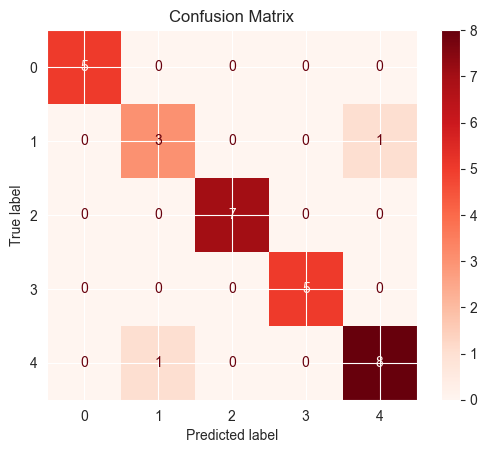

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(pipeline_xgb, X_test, Y_test, cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

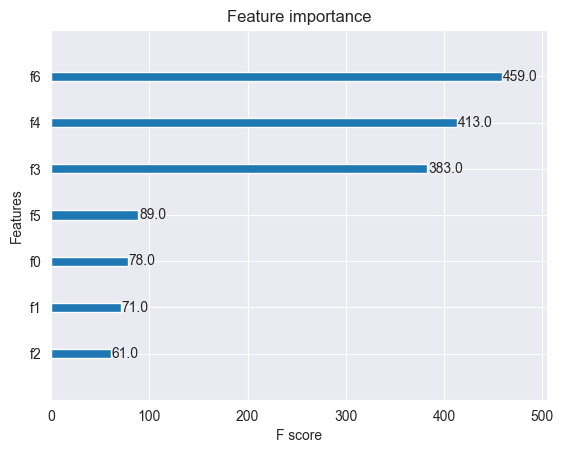

In [40]:
from xgboost import plot_importance
xgb_model = pipeline_xgb.named_steps['XG Boost']
plot_importance(xgb_model)

##### *LOGISTIC REGRESSION*

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
lr = LogisticRegression()

In [43]:
pipeline_lr = Pipeline(
    steps = [
        ("preprocess",preprocessor),
        ("Logistic",lr)
    ]
)

In [44]:
pipeline_lr.fit(X_train,Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Scaling',
                                                                   StandardScaler())]),
                                                  ['N', 'P', 'K',
                                                   'Temperature_C',
                                                   'Humidity_%', 'pH',
                                                   'Rainfall_mm'])])),
                ('Logistic', LogisticRegression())])

In [45]:
pred_lr = pipeline_lr.predict(X_test)

In [46]:
acc_lr = accuracy_score(Y_test,pred_lr) * 100
pre_lr = precision_score(Y_test,pred_lr,average='weighted', zero_division=0) * 100
recall_lr = recall_score(Y_test,pred_lr,average='weighted', zero_division=0) * 100
f1_lr = f1_score(Y_test,pred_lr,average='weighted', zero_division=0) * 100

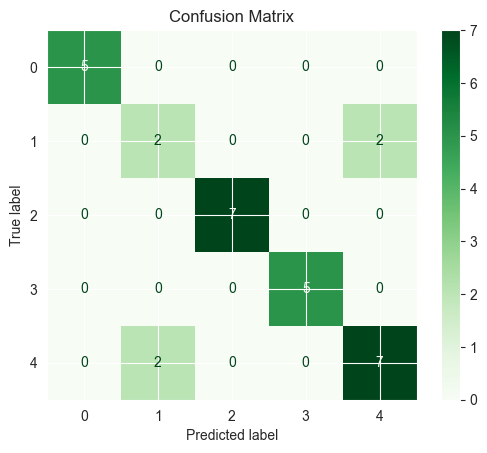

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(pipeline_lr, X_test, Y_test, cmap='Greens')
plt.title('Confusion Matrix')
plt.show()

##### *Models Comparison*

In [48]:
a = {
    "Models" : ["LogisticRegression","RandomForestClassifier","XG Boost"],
    "Accuracy" : [acc_lr,acc_rf,acc_xgb],
    "Precision" : [pre_lr,pre_rf,pre_xgb],
    "Recall" : [recall_lr,recall_rf,recall_xgb],
    "F1 Score": [f1_lr,f1_rf,f1_xgb]
}
models = pd.DataFrame(a)

In [49]:
models

,Models,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,86.666667,86.666667,86.666667,86.666667
1,RandomForestClassifier,93.333333,93.333333,93.333333,93.333333
2,XG Boost,93.333333,93.333333,93.333333,93.333333


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

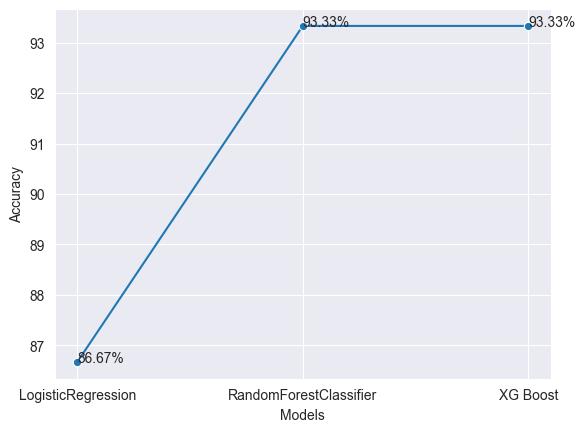

In [51]:
ax = sns.lineplot(x='Models', y='Accuracy', data=models, marker='o')
for x, y in zip(models['Models'], models['Accuracy']):
    ax.text(x, y, f"{y:.2f}%")

plt.show()

In [52]:
import joblib

# --- Determine Best Model ---
best_model_name = models.loc[models['Accuracy'].idxmax(), 'Models']

if best_model_name == "RandomForestClassifier":
    best_model = pipeline_rf
elif best_model_name == "XG Boost":
    best_model = pipeline_xgb
else:
    best_model = pipeline_lr

# --- Save Best Model ---
joblib.dump(best_model, "model.pkl")
print("model.pkl saved!")

# --- Save Label Encoder ---
joblib.dump(encoder, "label_encoder.pkl")
print("label_encoder.pkl saved!")

# --- Save Accuracy Details ---
accuracy_details = {
    "LogisticRegression": {
        "Accuracy": acc_lr,
        "Precision": pre_lr,
        "Recall": recall_lr,
        "F1": f1_lr
    },
    "RandomForestClassifier": {
        "Accuracy": acc_rf,
        "Precision": pre_rf,
        "Recall": recall_rf,
        "F1": f1_rf
    },
    "XG Boost": {
        "Accuracy": acc_xgb,
        "Precision": pre_xgb,
        "Recall": recall_xgb,
        "F1": f1_xgb
    },
    "BestModel": best_model_name
}

joblib.dump(accuracy_details, "accuracy.pkl")
print("accuracy.pkl saved!")


model.pkl saved!
label_encoder.pkl saved!
accuracy.pkl saved!


#### ***Crop Recommendation***

In [53]:
crop_data.columns

Index(['Humidity_%', 'Temperature_C', 'Rainfall_mm', 'N', 'P', 'K', 'pH',
       'Crop_Name'],
      dtype='object')

In [54]:
print(f"pH value between {crop_data['pH'].min()} and {crop_data['pH'].max()}")
print(f"N value between {crop_data['N'].min()} and {crop_data['N'].max()}")
print(f"P value between {crop_data['P'].min()} and {crop_data['P'].max()}")
print(f"K value between {crop_data['K'].min()} and {crop_data['K'].max()}")
print(f"Humidity value between {crop_data['Humidity_%'].min()} and {crop_data['Humidity_%'].max()}")
print(f"Temperature_C value between {crop_data['Temperature_C'].min()} and {crop_data['Temperature_C'].max()}")
print(f"Rainfall_mm value between {crop_data['Rainfall_mm'].min()} and {crop_data['Rainfall_mm'].max()}")

pH value between 5.88965 and 6.98335
N value between 79.68 and 132.28
P value between 116.12 and 183.586667
K value between 109.153333 and 148.753333
Humidity value between 24.2 and 96.3
Temperature_C value between 9.6 and 36.8
Rainfall_mm value between 10 and 1615
